# M11.13 — Real-event domain-transfer validation

**Does M11 reduce the synthetic-to-real gap relative to M10 while preserving useful parameter estimates and conformal uncertainty?**

GW170814, H1/L1/V1. Comparación emparejada sobre el mismo strain, PSD y offset;
ningún entrenamiento, calibración, selección conformal o ajuste contra LVK.
Ejecutar por secciones, no Run All. Las conclusiones se completan sólo tras ejecutar.

**Limitación comprobada al construir este notebook:** M11.12 exporta selecciones y
métricas, pero explícitamente no serializa los calibradores ajustados. M10.12/13
los reajustan desde cal. Eso está prohibido aquí. Sin estado congelado verificable,
los intervalos se registran como `missing_frozen_state`, nunca se reconstruyen desde
CSV de métricas ni se presentan como intervalos disponibles. El resto del análisis
es independiente. La comparación científica completa queda pendiente de ese estado.

## 1. Imports y rutas

In [10]:
from pathlib import Path
import sys, json, hashlib, pickle, platform
import urllib.request
import numpy as np
import pandas as pd
import h5py
import torch
import matplotlib.pyplot as plt
from IPython.display import display

root = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
             if (p / "src/paths.py").is_file()), None)
if root is None:
    raise RuntimeError("Abrir desde el repositorio cbc_pe")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from src.paths import resolve_project_root, resolve_data_root, resolve_processed_artifact
from src.config import SimulationConfig
from src.processing import SignalProcessor
from src.models.network import SimpleCNN_ResidualDilated
from src.models.evaluate import extract_predictions_and_embeddings
from torch.utils.data import TensorDataset, DataLoader
from pycbc.types import TimeSeries as PyCBCTimeSeries
from pycbc.psd import interpolate, inverse_spectrum_truncation
from src.conformal.selected_calibrators import apply_selected_calibrators, SelectedMondrianCalibrator
from src.evaluation.lvk import add_lvk_comparison_metrics
from src.real_data.lvk_reference import build_lvk_reference_detector_frame

PROJECT_ROOT = resolve_project_root()
def read_json(path):
    return json.loads(Path(path).read_text())
def require(condition, message):
    if not condition:
        raise ValueError(message)
def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

TRAIN_PATHS = {
    "M10": PROJECT_ROOT / "configs/experiments/train_500k_M10_inputzscore_resdilated_emb64_d124_bs256_seed123.json",
    "M11": PROJECT_ROOT / "configs/experiments/train_m11_final_G1_500k.json",
}
GEN_PATHS = {
    "M10": PROJECT_ROOT / "configs/generation/generate_500k_bbh_4s.json",
    "M11": PROJECT_ROOT / "configs/generation/generate_m11_final_G1_500k.json",
}
train_configs = {m: read_json(p) for m, p in TRAIN_PATHS.items()}
gen_configs = {m: read_json(p) for m, p in GEN_PATHS.items()}
DATA_ROOT = resolve_data_root(config_data_root=train_configs["M11"]["data_root"])
LABELS = ["chirp_mass", "total_mass", "chi_eff"]
DETECTORS = ["H1", "L1", "V1"]
EVENT = "GW170814"
DATASET_IDS = {m: c["dataset"]["dataset_id"] for m, c in train_configs.items()}
RESULT_DIRS = {m: DATA_ROOT / "results" / d for m, d in DATASET_IDS.items()}
CHECKPOINTS = {}
for m, cfg in train_configs.items():
    name = (f'{DATASET_IDS[m]}_SimpleCNN_ResidualDilated_'
            f'{cfg["outputs"]["checkpoint_tag"]}_MSELoss_seed123_checkpoint.pt')
    parent = DATA_ROOT / "models/checkpoints"
    candidates = [parent / DATASET_IDS[m] / name, parent / name]
    CHECKPOINTS[m] = next((p for p in candidates if p.is_file()), candidates[0])
PREDICTION_PATHS = {
    "M10": RESULT_DIRS["M10"] / "m10_inputzscore_500k_cal_test_predictions_embeddings.npz",
    "M11": RESULT_DIRS["M11"] / "m11_final_G1_500k_cal_test_predictions_embeddings.npz",
}
if not PREDICTION_PATHS["M10"].is_file():
    PREDICTION_PATHS["M10"] = DATA_ROOT / "results" / PREDICTION_PATHS["M10"].name
SELECTION_PATHS = {
    "M10": DATA_ROOT / "results/mondrian_M10_final_baseline/selected_configurations.csv",
    "M11": RESULT_DIRS["M11"] / "mondrian_m11_selected_from_val.csv",
}
M11_CONFORMAL_PROVENANCE = RESULT_DIRS["M11"] / "mondrian_m11_cal_val_test_provenance.json"
LVK_PATH = DATA_ROOT / "lvk_references/GWTC-3-confident_detector_frame_reference_error_propagated.csv"
LVK_REFERENCE_URL = "https://gwosc.org/eventapi/json/GWTC-1-confident/GW170814/v3/"
LVK_POSTERIOR_URL = "https://dcc.ligo.org/public/0157/P1800370/005/GW170814_GWTC-1.hdf5"
LVK_POSTERIOR_PATH = DATA_ROOT / "lvk_references/GW170814_GWTC-1.hdf5"
LVK_POSTERIOR_SHA256 = "bf83e69f19aa24cffbaaa3a543928a398e3952543bf01e710cda0a61564f98c2"
GWOSC_CACHE_DIR = PROJECT_ROOT / "notebooks/gwosc_cache"
CACHE_SEARCH_DIRS = [GWOSC_CACHE_DIR, PROJECT_ROOT / "gwosc_cache",
                     PROJECT_ROOT / "notebooks/m11/gwosc_cache"]
OUTPUT_DIR = RESULT_DIRS["M11"] / "real_events" / EVENT
FIGURE_DIR = OUTPUT_DIR / "figures"
# Expected external exports; these paths do NOT exist yet and are not created here.
FROZEN_BUNDLE_PATHS = {
    "M10": DATA_ROOT / "results/mondrian_M10_final_baseline/selected_calibrators_frozen.pkl",
    "M11": RESULT_DIRS["M11"] / "mondrian_m11_selected_calibrators_frozen.pkl",
}
path_rows = []
for role, paths in [("checkpoint", CHECKPOINTS), ("prediction metadata", PREDICTION_PATHS),
                    ("selection", SELECTION_PATHS), ("training config", TRAIN_PATHS),
                    ("generation config", GEN_PATHS), ("external frozen calibrators (pending)", FROZEN_BUNDLE_PATHS)]:
    path_rows.extend(dict(model=m, role=role, path=str(p), exists=p.is_file()) for m, p in paths.items())
path_rows.extend(dict(model="shared", role=role, path=str(p), exists=p.exists())
                 for role, p in [("historical LVK CSV (audit only)", LVK_PATH),
                                 ("GWTC-1 posterior (download if absent)", LVK_POSTERIOR_PATH),
                                 ("GWOSC cache", GWOSC_CACHE_DIR),
                                 ("M11 conformal provenance", M11_CONFORMAL_PROVENANCE)])
path_audit = pd.DataFrame(path_rows)
with pd.option_context("display.max_colwidth", None, "display.max_rows", 30):
    display(path_audit)
print("Results:", OUTPUT_DIR, "Figures:", FIGURE_DIR)

,model,role,path,exists
0,M10,checkpoint,/data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt,True
1,M11,checkpoint,/data/vserrano/cbc_pe_data/models/checkpoints/M11_final_G1_500k/M11_final_G1_500k_SimpleCNN_ResidualDilated_M11_final_G1_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt,True
2,M10,prediction metadata,/data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_cal_test_predictions_embeddings.npz,True
3,M11,prediction metadata,/data/vserrano/cbc_pe_data/results/M11_final_G1_500k/m11_final_G1_500k_cal_test_predictions_embeddings.npz,True
4,M10,selection,/data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/selected_configurations.csv,True
5,M11,selection,/data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_selected_from_val.csv,True
6,M10,training config,/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/configs/experiments/train_500k_M10_inputzscore_resdilated_emb64_d124_bs256_seed123.json,True
7,M11,training config,/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/configs/experiments/train_m11_final_G1_500k.json,True
8,M10,generation config,/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/configs/generation/generate_500k_bbh_4s.json,True
9,M11,generation config,/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/configs/generation/generate_m11_final_G1_500k.json,True


Results: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/real_events/GW170814 Figures: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/real_events/GW170814/figures


## 2. Contratos congelados

M10/G0 designa aquí el dominio analítico histórico M10, no el predictor M11.6 G0.
Ambas masas son las masas que entran en la forma de onda observada (detector frame);
no se aplica redshift a la salida CNN. Cada modelo conserva su scaler train-only.
M11 almacena inputs ya normalizados; M10 normaliza al cargarlos. El strain real aún
no está normalizado: se aplica una sola operación explícita antes de ambos modelos.

Diferencias que limitan una atribución exclusivamente al ruido: datasets/fuentes
sintéticas distintos, entorno/proyección temporal M11, PSD empírico de generación
M11 de 128 s, SNR M11 calculado en 30–512 Hz (M10 usa el cutoff superior por defecto
`None`), y selección conformal M10 sobre test frente a M11 sobre val. No se cambia
ninguna de estas políticas. El experimento compara los dos sistemas finales.

In [11]:
gen_cfg = gen_configs["M10"]
fs = 4096
final_duration = 4.0
context_start = context_end = 1664
final_length = 16384
processing_length = 19712
processing_delta_f = fs / processing_length
processing_flength = processing_length // 2 + 1
REAL_DETECTORS = DETECTORS
require(gen_cfg["signal_processor"] == gen_configs["M11"]["signal_processor"], "Preprocessing incompatible")
for m, cfg in gen_configs.items():
    require(cfg["detectors"] == DETECTORS, f"Detector order {m}")
    for key, value in [("duration", 4.0), ("processing_context_start_samples", 1664),
                       ("processing_context_end_samples", 1664)]:
        require(cfg["simulation"][key] == value, f"Contrato {m}: {key}")
sim_config = SimulationConfig(duration=final_duration,
    processing_context_start_samples=context_start, processing_context_end_samples=context_end)
processor = SignalProcessor(config=sim_config, **gen_cfg["signal_processor"])
require(sim_config.sampling_frequency == fs and sim_config.processing_length == processing_length,
        "SimulationConfig defaults changed")
require(processor.apply_standardization is False, "No doble normalización")
require(gen_configs["M11"]["final_input_normalization"] ==
        {"mode": "per_sample_per_detector_zscore", "epsilon": 1e-6}, "M11 normalization")
contracts = pd.DataFrame([
    dict(model=m, architecture=c["model"]["class_name"],
         training_domain="analytical-PSD Gaussian (historical G0)" if m == "M10" else "empirical-PSD Gaussian G1",
         normalization="per sample/detector zscore eps=1e-6", sampling_rate=fs,
         duration_s=final_duration, filter_band_Hz="30–512", snr_range="10–25",
         snr_frequency_band="30–Nyquist (default upper=None)" if m == "M10" else "30–512",
         normalization_location="loader" if m == "M10" else "stored dataset",
         conformal_selection="test (historical)" if m == "M10" else "val")
    for m, c in train_configs.items()])
display(contracts)
display(pd.Series(processor.metadata(), name="shared real preprocessing"))

models, scalers, checkpoint_metadata = {}, {}, {}
for m, path in CHECKPOINTS.items():
    if not path.is_file():
        raise FileNotFoundError(path)
    checkpoint = torch.load(path, map_location="cpu")
    config = checkpoint["model_config"]
    require(config["dataset_id"] == DATASET_IDS[m], f"Wrong dataset {m}")
    require(config["label_names"] == LABELS, f"Label order {m}")
    require(config["model_kwargs"] == train_configs[m]["model"]["kwargs"], f"Architecture {m}")
    require(config["input_normalization"] == train_configs[m]["input_normalization"], f"Normalization {m}")
    require(config["signal_length"] == final_length and config["n_detectors"] == 3, f"Shape {m}")
    mean, std = [np.asarray(checkpoint[k], dtype=np.float64) for k in ("y_mean", "y_std")]
    require(mean.shape == std.shape == (3,) and np.isfinite(mean).all()
            and np.isfinite(std).all() and (std > 0).all(), f"Scaler {m}")
    with np.load(PREDICTION_PATHS[m], allow_pickle=True) as z:
        require(z["label_names"].tolist() == LABELS, f"NPZ labels {m}")
        require(np.array_equal(z["y_mean"], mean) and np.array_equal(z["y_std"], std), f"NPZ scaler {m}")
        require(Path(z["checkpoint_file"].item()).name == path.name, f"NPZ checkpoint {m}")
    model = SimpleCNN_ResidualDilated(**config["model_kwargs"])
    model.load_state_dict(checkpoint["model_state_dict"], strict=True)
    models[m] = model.cpu().eval()
    scalers[m] = (mean, std)
    checkpoint_metadata[m] = config
    del checkpoint

,model,architecture,training_domain,normalization,sampling_rate,duration_s,filter_band_Hz,snr_range,snr_frequency_band,normalization_location,conformal_selection
0,M10,SimpleCNN_ResidualDilated,analytical-PSD Gaussian (historical G0),per sample/detector zscore eps=1e-6,4096,4.0,30–512,10–25,30–Nyquist (default upper=None),loader,test (historical)
1,M11,SimpleCNN_ResidualDilated,empirical-PSD Gaussian G1,per sample/detector zscore eps=1e-6,4096,4.0,30–512,10–25,30–512,stored dataset,val


whitening_method                                                                        psd
apply_lowpass                                                                          True
apply_highpass                                                                         True
apply_standardization                                                                 False
lowpass_frequency                                                                     512.0
highpass_frequency                                                                     30.0
whitening_low_frequency_cutoff                                                         30.0
whitening_max_filter_duration                                                           0.5
whitening_trunc_method                                                                 hann
fir_order                                                                               256
fir_beta                                                                        

## 3. Datos GW170814 y caché M10

GPS **1186741861.5**, GWOSC **O2_4KHZ_R1**, mismos archivos de 4096 s del notebook 12.
Se busca primero la caché histórica; archivos existentes nunca se reemplazan.
Un archivo corrupto produce error. Se registra finitud del archivo completo y se
exige cobertura/finitud en **todas** las ventanas necesarias; NaN fuera de ellas
se informa sin interpolar, rellenar o modificar strain.

In [12]:
event_name = "GW170814"
event_time = 1186741861.5

REAL_DETECTORS = ["H1", "L1", "V1"]

GWOSC_URLS_4096 = {
    "H1": "https://gwosc.org/archive/data/O2_4KHZ_R1/1185939456/H-H1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5",
    "L1": "https://gwosc.org/archive/data/O2_4KHZ_R1/1185939456/L-L1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5",
    "V1": "https://gwosc.org/archive/data/O2_4KHZ_R1/1185939456/V-V1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5",
}

In [13]:
def download_if_needed(url, cache_dir=GWOSC_CACHE_DIR):
    filename = url.split("/")[-1]
    local_path = cache_dir / filename

    if not local_path.exists():
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, local_path)
    else:
        print(f"Using cached file: {filename}")

    return local_path


def read_gwosc_hdf5_as_pycbc_timeseries(path):
    with h5py.File(path, "r") as f:
        strain = f["strain"]["Strain"][:].astype(np.float64)
        gps_start = float(f["meta"]["GPSstart"][()])
        duration = float(f["meta"]["Duration"][()])
        delta_t = duration / len(strain)

    return PyCBCTimeSeries(
        strain,
        delta_t=delta_t,
        epoch=gps_start,
    )

## 4. Ventanas PSD y offsets predefinidos

Notebook 12, celdas 38 y 42 (índices base cero). Se evalúa el producto de las seis
ventanas por los trece offsets: 78 entradas compartidas. La comparación PSD
principal fija offset=0; la comparación temporal principal fija PSD=(-512,-128).
El producto completo es una extensión explícita de los dos barridos separados M10.
La PSD se referencia al **centro desplazado**, exactamente como el helper M10;
por tanto sensibilidad temporal incluye el desplazamiento de la ventana PSD.
No se elige una ventana usando LVK.

In [14]:
PSD_WINDOWS = [(-1600.0, -1216.0), (-1400.0, -1016.0), (-1200.0, -816.0),
               (-1024.0, -640.0), (-768.0, -384.0), (-512.0, -128.0)]
CENTER_OFFSETS = np.array([-1.50, -1.25, -1.00, -0.75, -0.50, -0.25, 0.00,
                            0.25, 0.50, 0.75, 1.00, 1.25, 1.50])
NOMINAL_PSD = (-512.0, -128.0)
raw_strains_4096, strain_paths, acquisition_rows = {}, {}, []
for ifo, url in GWOSC_URLS_4096.items():
    filename = url.rsplit("/", 1)[-1]
    local = next((folder / filename for folder in CACHE_SEARCH_DIRS
                  if (folder / filename).is_file()), None)
    if local is None:
        GWOSC_CACHE_DIR.mkdir(parents=True, exist_ok=True)
        local = download_if_needed(url)
    ts = read_gwosc_hdf5_as_pycbc_timeseries(local)
    require(float(ts.sample_rate) == fs, f"Sample rate {ifo}")
    acquisition_rows.append(dict(detector=ifo, path=str(local), url=url,
        start=float(ts.start_time), end=float(ts.end_time), sample_rate=float(ts.sample_rate),
        whole_file_finite=bool(np.isfinite(ts.numpy()).all())))
    for offset in CENTER_OFFSETS:
        center = event_time + float(offset)
        windows = [(center-2-context_start/fs, center+2+context_end/fs)]
        windows += [(center+a, center+b) for a, b in PSD_WINDOWS]
        for start, end in windows:
            require(float(ts.start_time) <= start < end <= float(ts.end_time),
                    f"Coverage {ifo}: {start}, {end}")
            segment = ts.time_slice(start, end)
            require(len(segment) == round((end-start)*fs) and np.isfinite(segment.numpy()).all(),
                    f"Invalid required strain {ifo}: {start}, {end}; no repair")
    strain_paths[ifo], raw_strains_4096[ifo] = local, ts
acquisition = pd.DataFrame(acquisition_rows)
display(acquisition)

,detector,path,url,start,end,sample_rate,whole_file_finite
0,H1,/afs/ciemat.es/user/v/vserrano/Desktop/gw/Grav...,https://gwosc.org/archive/data/O2_4KHZ_R1/1185...,1.186738e+09,1.186742e+09,4096.0,True
1,L1,/afs/ciemat.es/user/v/vserrano/Desktop/gw/Grav...,https://gwosc.org/archive/data/O2_4KHZ_R1/1185...,1.186738e+09,1.186742e+09,4096.0,True
2,V1,/afs/ciemat.es/user/v/vserrano/Desktop/gw/Grav...,https://gwosc.org/archive/data/O2_4KHZ_R1/1185...,1.186738e+09,1.186742e+09,4096.0,True


## 5. Preprocessing real — reproducción del notebook 12

Helpers de sus celdas 25/26/17, sin cambio numérico. Welch `TimeSeries.psd(8.0)`,
interpolación a 4096/19712 Hz, inverse-spectrum truncation 0.5 s Hann, cutoff 30 Hz,
longitud PSD 9857. `SignalProcessor` vuelve a acondicionar ese PSD (comportamiento
histórico preservado), whitening, highpass 30, lowpass 512, FIR order 256 beta 5,
remove corrupted y crop 4 s. Contexto 1664 muestras/lado. Z-score float32,
std poblacional (ddof=0), denominador std+1e-6, **una vez** después del crop.

In [15]:
def estimate_offsource_psd_long(
    strain,
    event_time,
    psd_start_offset=-512.0,
    psd_end_offset=-128.0,
    psd_segment_duration=8.0,
    low_frequency_cutoff=30.0,
    max_filter_duration=0.5,
):
    psd_start = event_time + psd_start_offset
    psd_end = event_time + psd_end_offset

    available_start = float(strain.start_time)
    available_end = float(strain.end_time)

    if psd_start < available_start or psd_end > available_end:
        raise ValueError(
            f"PSD window [{psd_start}, {psd_end}] outside available "
            f"[{available_start}, {available_end}]"
        )

    psd_data = strain.time_slice(psd_start, psd_end)

    psd = psd_data.psd(psd_segment_duration)
    psd = interpolate(psd, processing_delta_f)

    max_filter_len = int(round(max_filter_duration * fs))

    psd = inverse_spectrum_truncation(
        psd,
        max_filter_len=max_filter_len,
        low_frequency_cutoff=low_frequency_cutoff,
        trunc_method="hann",
    )

    if len(psd) > processing_flength:
        psd = psd[:processing_flength]
    elif len(psd) < processing_flength:
        raise ValueError(f"PSD too short: {len(psd)} < {processing_flength}")

    if not np.all(np.isfinite(psd.numpy())):
        raise ValueError("PSD contains non-finite values.")

    return psd

In [16]:
def build_real_input_like_training(
    *,
    raw_strains_long,
    center_time,
    processor,
    psd_start_offset=-512.0,
    psd_end_offset=-128.0,
    psd_segment_duration=8.0,
):
    """
    Build one real HLV input using the same preprocessing contract as the frozen M10 real-event pipeline.

    The final 4 s output window is centered at `center_time`.
    The input to SignalProcessor includes the same processing context used in training.
    """
    output_start = center_time - final_duration / 2
    output_end = center_time + final_duration / 2

    processing_start = output_start - context_start / fs
    processing_end = output_end + context_end / fs

    real_segments = {}

    for ifo in REAL_DETECTORS:
        seg = raw_strains_long[ifo].time_slice(processing_start, processing_end)

        if len(seg) != processing_length:
            raise ValueError(
                f"{ifo}: expected {processing_length}, got {len(seg)}"
            )

        real_segments[ifo] = seg

    psds = {}

    for ifo in REAL_DETECTORS:
        psds[ifo] = estimate_offsource_psd_long(
            raw_strains_long[ifo],
            event_time=center_time,
            psd_start_offset=psd_start_offset,
            psd_end_offset=psd_end_offset,
            psd_segment_duration=psd_segment_duration,
            low_frequency_cutoff=30.0,
            max_filter_duration=0.5,
        )

    processed = processor.process_network(
        strains=real_segments,
        psds=psds,
    )

    X = np.stack(
        [processed[ifo].numpy() for ifo in REAL_DETECTORS],
        axis=0,
    ).astype(np.float32)

    X = X[None, :, :]

    if X.shape != (1, 3, 16384):
        raise ValueError(f"Bad X shape: {X.shape}")

    if not np.all(np.isfinite(X)):
        raise ValueError("X contains non-finite values.")

    return X, processed, psds, real_segments

In [17]:
def zscore_per_sample_per_detector_np(X, eps=1e-6):
    """
    X shape:
        (N, C, T) or (C, T)

    Applies per-sample, per-detector/channel z-score normalization.
    """
    X = np.asarray(X, dtype=np.float32)

    if X.ndim == 2:
        mean = X.mean(axis=1, keepdims=True)
        std = X.std(axis=1, keepdims=True)
        return ((X - mean) / (std + eps)).astype(np.float32)

    if X.ndim == 3:
        mean = X.mean(axis=2, keepdims=True)
        std = X.std(axis=2, keepdims=True)
        return ((X - mean) / (std + eps)).astype(np.float32)

    raise ValueError(f"Expected X shape (C,T) or (N,C,T), got {X.shape}")

## 6. Inferencia emparejada y diagnósticos por detector

In [18]:
@torch.no_grad()
def predict_frozen(model, X, mean, std):
    # Same extractor as notebook 12 cell 16, with explicit model-specific scalers.
    require(X.shape == (1, 3, 16384) and np.isfinite(X).all(), "Invalid CNN input")
    loader = DataLoader(TensorDataset(torch.from_numpy(X.astype(np.float32)),
        torch.zeros((1, 3), dtype=torch.float32)), batch_size=1, shuffle=False, num_workers=0)
    pred, emb, _ = extract_predictions_and_embeddings(model=model, loader=loader, device="cpu")
    physical = pred * std[None, :] + mean[None, :]
    require(pred.shape == physical.shape == (1, 3), "Output shape")
    require(emb.shape == (1, 64), "Embedding shape")
    require(all(np.isfinite(a).all() for a in (pred, physical, emb)), "Nonfinite inference")
    return pred, physical, emb

def scale_stats(array):
    a = np.asarray(array, dtype=np.float64)
    require(np.isfinite(a).all(), "Nonfinite diagnostic input")
    return dict(mean=float(a.mean()), std=float(a.std()), rms=float(np.sqrt(np.mean(a*a))),
                maxabs=float(np.abs(a).max()), finite=True)

prediction_rows, diagnostic_rows, input_hash_rows = [], [], []
inference_arrays = {m: dict(pred=[], emb=[]) for m in models}
for window_index, (start, end) in enumerate(PSD_WINDOWS):
    print("PSD window", window_index, (start, end))
    for offset in CENTER_OFFSETS:
        sample_index = len(input_hash_rows)
        meta = dict(sample_index=sample_index, psd_window=window_index,
                    psd_start_offset=start, psd_end_offset=end, center_offset_s=float(offset))
        X_pre, processed, psds, segments = build_real_input_like_training(
            raw_strains_long=raw_strains_4096, center_time=event_time+float(offset),
            processor=processor, psd_start_offset=start, psd_end_offset=end, psd_segment_duration=8.0)
        X = zscore_per_sample_per_detector_np(X_pre, eps=1e-6)
        require(X.shape == (1, 3, 16384) and np.isfinite(X).all(), "Input contract")
        require(np.allclose(X.mean(axis=-1), 0, atol=2e-6), "Post-zscore mean")
        expected_std = X_pre.std(axis=-1) / (X_pre.std(axis=-1) + 1e-6)
        require(np.allclose(X.std(axis=-1), expected_std, atol=2e-6), "Zscore std contract")
        fingerprint = hashlib.sha256(X.tobytes()).hexdigest()
        input_hash_rows.append(dict(**meta, input_sha256=fingerprint, shape="1,3,16384", zscore_count=1))
        for j, ifo in enumerate(DETECTORS):
            for stage, arr in [("raw_context", segments[ifo].numpy()),
                               ("pre_zscore", X_pre[0,j]), ("post_zscore", X[0,j])]:
                diagnostic_rows.append(dict(**meta, detector=ifo, stage=stage, **scale_stats(arr)))
        for m, model in models.items():
            pred, physical, emb = predict_frozen(model, X, *scalers[m])
            require(hashlib.sha256(X.tobytes()).hexdigest() == fingerprint, "Input mutated")
            inference_arrays[m]["pred"].append(pred[0])
            inference_arrays[m]["emb"].append(emb[0])
            for j, label in enumerate(LABELS):
                prediction_rows.append(dict(**meta, event=EVENT, model=m, label=label,
                    pred_std=float(pred[0,j]), pred_phys=float(physical[0,j]),
                    frame="detector" if label != "chi_eff" else "dimensionless",
                    units="Msun" if label != "chi_eff" else "1", input_sha256=fingerprint))
preprocessing_diagnostics = pd.DataFrame(diagnostic_rows)
predictions = pd.DataFrame(prediction_rows)
input_manifest = pd.DataFrame(input_hash_rows)
for arrays in inference_arrays.values():
    for key in arrays:
        arrays[key] = np.stack(arrays[key])
require(len(input_manifest) == 78 and len(predictions) == 468, "Incomplete paired grid")
display(predictions.head(6))

PSD window 0 (-1600.0, -1216.0)
PSD window 1 (-1400.0, -1016.0)
PSD window 2 (-1200.0, -816.0)
PSD window 3 (-1024.0, -640.0)
PSD window 4 (-768.0, -384.0)
PSD window 5 (-512.0, -128.0)


,sample_index,psd_window,psd_start_offset,psd_end_offset,center_offset_s,event,model,label,pred_std,pred_phys,frame,units,input_sha256
0,0,0,-1600.0,-1216.0,-1.5,GW170814,M10,chirp_mass,-0.760842,24.910356,detector,Msun,9bc53c2d100cf9ec2e2021c78fcf9b7485f4e21d58a4b5...
1,0,0,-1600.0,-1216.0,-1.5,GW170814,M10,total_mass,-1.024536,59.473630,detector,Msun,9bc53c2d100cf9ec2e2021c78fcf9b7485f4e21d58a4b5...
2,0,0,-1600.0,-1216.0,-1.5,GW170814,M10,chi_eff,-0.473577,-0.207756,dimensionless,1,9bc53c2d100cf9ec2e2021c78fcf9b7485f4e21d58a4b5...
3,0,0,-1600.0,-1216.0,-1.5,GW170814,M11,chirp_mass,-0.738297,25.275701,detector,Msun,9bc53c2d100cf9ec2e2021c78fcf9b7485f4e21d58a4b5...
4,0,0,-1600.0,-1216.0,-1.5,GW170814,M11,total_mass,-0.997426,60.372026,detector,Msun,9bc53c2d100cf9ec2e2021c78fcf9b7485f4e21d58a4b5...
5,0,0,-1600.0,-1216.0,-1.5,GW170814,M11,chi_eff,-0.217802,-0.096126,dimensionless,1,9bc53c2d100cf9ec2e2021c78fcf9b7485f4e21d58a4b5...


## 7. Sensibilidad temporal

Estadísticos poblacionales ddof=0. Desviación respecto al offset cero de la **misma**
ventana PSD; se guardan diferencias firmadas y absolutas por offset. La tabla
principal usa la PSD nominal M10, y se conservan todas las demás.

In [19]:
center = predictions[predictions.center_offset_s == 0][["model", "label", "psd_window", "pred_phys"]]
timing_deviations = predictions.merge(center.rename(columns={"pred_phys": "center_prediction"}),
    on=["model", "label", "psd_window"], validate="many_to_one")
timing_deviations["deviation_from_center"] = timing_deviations.pred_phys - timing_deviations.center_prediction
timing_deviations["abs_deviation_from_center"] = timing_deviations.deviation_from_center.abs()
timing_sensitivity = timing_deviations.groupby(["model", "label", "psd_window"], as_index=False).agg(
    count=("pred_phys", "size"), mean=("pred_phys", "mean"),
    std=("pred_phys", lambda x: np.std(x, ddof=0)), minimum=("pred_phys", "min"),
    maximum=("pred_phys", "max"), max_abs_deviation=("abs_deviation_from_center", "max"))
timing_sensitivity["range"] = timing_sensitivity.maximum - timing_sensitivity.minimum
nominal_index = PSD_WINDOWS.index(NOMINAL_PSD)
display(timing_sensitivity[timing_sensitivity.psd_window == nominal_index])

,model,label,psd_window,count,mean,std,minimum,maximum,max_abs_deviation,range
5,M10,chi_eff,5,13,-0.206805,0.019972,-0.263136,-0.182428,0.052267,0.080708
11,M10,chirp_mass,5,13,25.139123,0.374096,24.105535,25.606571,1.271239,1.501036
17,M10,total_mass,5,13,59.964276,0.822130,57.576518,60.977079,2.731977,3.400561
23,M11,chi_eff,5,13,-0.094976,0.004276,-0.100941,-0.085324,0.011435,0.015617
29,M11,chirp_mass,5,13,25.328054,0.064119,25.237809,25.444591,0.106092,0.206782
35,M11,total_mass,5,13,60.437426,0.103364,60.268581,60.605077,0.188389,0.336496


## 8. Sensibilidad PSD — offsets fijos, sin mezclar ambas variaciones

In [20]:
psd_sensitivity = predictions.groupby(["model", "label", "center_offset_s"], as_index=False).agg(
    count=("pred_phys", "size"), mean=("pred_phys", "mean"),
    std=("pred_phys", lambda x: np.std(x, ddof=0)), minimum=("pred_phys", "min"), maximum=("pred_phys", "max"))
psd_sensitivity["range"] = psd_sensitivity.maximum - psd_sensitivity.minimum
display(psd_sensitivity[psd_sensitivity.center_offset_s == 0])

,model,label,center_offset_s,count,mean,std,minimum,maximum,range
6,M10,chi_eff,0.0,6,-0.210013,0.004034,-0.217462,-0.205483,0.011979
19,M10,chirp_mass,0.0,6,25.402363,0.016016,25.376774,25.419274,0.042500
32,M10,total_mass,0.0,6,60.343924,0.062013,60.231227,60.432048,0.200820
45,M11,chi_eff,0.0,6,-0.097018,0.001240,-0.098730,-0.095566,0.003163
58,M11,chirp_mass,0.0,6,25.346025,0.023261,25.318927,25.385147,0.066220
71,M11,total_mass,0.0,6,60.449825,0.070069,60.363343,60.553800,0.190457


## 9. Mondrian — sólo aplicar estado previamente ajustado

Se leen las decisiones congeladas; `no_strict_candidate` se conserva sin fallback.
Los CSV de selección **no contienen** bins/cuantiles/KNN. Tampoco los intervalos de
un evento anterior permiten aplicar el sistema a nuevas predicciones.

Rutas **esperadas para los futuros exports externos**, relativas a `DATA_ROOT`:
- M10: `results/mondrian_M10_final_baseline/selected_calibrators_frozen.pkl`
- M11: `results/M11_final_G1_500k/mondrian_m11_selected_calibrators_frozen.pkl`

No existen todavía; son el contrato de entrega acordado, no artefactos encontrados.
El usuario los generará fuera de M11.13 con las selecciones finales y exclusivamente
el cal correspondiente, sin reselección. El adaptador de abajo admite, cuando exista, un pickle propio de confianza con
`calibrators` (dict `(policy,label)` → `SelectedMondrianCalibrator` del repositorio)
y `metadata` con `checkpoint_sha256`, `selection_sha256`, `label_names`, `y_mean`,
`y_std`, `calibration_space='standardized'`, `fit_split='cal'`, `selection_split`
(`test` M10 / `val` M11), `predictions_path`, `predictions_sha256`,
`cal_split_path`, `cal_split_sha256`, `idx_cal_sha256` (SHA256 de índices cal
convertidos a int64 contiguos), `confidence_level=0.9`, `n_neighbors=5`,
`min_samples_per_bin=20` y `apply_jitter=True`.
Los objetos `fitted` deben contener `binner` con bordes, `calibrator.intervals_`
con ambos offsets (incluidas colas asimétricas), y `difficulty_model` con referencia
KNN/embeddings/residuos cal cuando proceda. **Este formato de entrada no es un export existente de
M11.12.** Es una interfaz preparada para los exports externos que generará el usuario.
No se crea ni se exporta ese bundle aquí. El jitter M10/M11 sin semilla implica
que un fit externo nuevo no garantiza igualdad bit a bit con los intervalos
históricos; se debe registrar esa nueva materialización y congelarla antes de
aplicarla a reales. Su selección sigue siendo la ya fijada.

Sin bundle se producen filas de intervalo con límites NaN y estado explícito.
No se calcula cobertura real, ni se interpreta ausencia como falta de solapamiento.

In [21]:
selections = {m: pd.read_csv(p) for m, p in SELECTION_PATHS.items()}
conformal_provenance = read_json(M11_CONFORMAL_PROVENANCE)
require([conformal_provenance[k] for k in ("fit_split", "selection_split", "evaluation_split")]
        == ["cal", "val", "test"], "M11 split roles")
require(conformal_provenance["calibration_space"] == "standardized", "Conformal units")
for m, selected in selections.items():
    require(not selected.duplicated(["final_policy", "label"]).any(), f"Duplicate selections {m}")
    require(set(zip(selected.final_policy, selected.label)) ==
            {(p, l) for p in ("conservative", "efficient") for l in LABELS}, f"Missing selection rows {m}")
    if m == "M10":
        selected["selection_status"] = "selected"
    else:
        require(set(selected.selection_status) <= {"selected", "no_strict_candidate"}, "Unknown selection status")
        require((selected.selection_split == "val").all(), "M11 selected outside val")
    display(selected[["final_policy", "label", "selection_status", "taxonomy_mode", "interval_mode", "n_bins"]])

frozen_systems, conformal_status = {}, []
for m, path in FROZEN_BUNDLE_PATHS.items():
    if not Path(path).is_file():
        frozen_systems[m] = None
        conformal_status.append(dict(model=m, status="missing_frozen_state", path=str(path)))
        print(m, "MISSING FROZEN STATE — intervals unavailable; no refit")
        continue
    path = Path(path)
    with path.open("rb") as stream:
        bundle = pickle.load(stream)
    metadata, systems = bundle["metadata"], bundle["calibrators"]
    require(metadata["checkpoint_sha256"] == sha256(CHECKPOINTS[m]), "Frozen checkpoint mismatch")
    require(metadata["selection_sha256"] == sha256(SELECTION_PATHS[m]), "Frozen selection mismatch")
    require(metadata["label_names"] == LABELS and metadata["calibration_space"] == "standardized", "Frozen units")
    require(metadata["fit_split"] == "cal" and metadata["selection_split"] ==
            ("test" if m == "M10" else "val"), "Frozen split roles")
    require(all(np.array_equal(metadata[k], a) for k,a in zip(("y_mean", "y_std"), scalers[m])), "Frozen scaler")
    require(metadata["confidence_level"] == 0.9 and metadata["n_neighbors"] == 5
            and metadata["min_samples_per_bin"] == 20 and metadata["apply_jitter"] is True,
            "Frozen conformal contract")
    require(metadata["predictions_sha256"] == sha256(PREDICTION_PATHS[m]), "Frozen prediction provenance")
    split_path = resolve_processed_artifact(data_root=DATA_ROOT, dataset_id=DATASET_IDS[m],
        file_name=train_configs[m]["dataset"]["split_file"])
    require(metadata["cal_split_sha256"] == sha256(split_path), "Frozen split provenance")
    with np.load(PREDICTION_PATHS[m], allow_pickle=True) as z:
        indices = np.ascontiguousarray(z["idx_cal"], dtype=np.int64)
        require(metadata["idx_cal_sha256"] == hashlib.sha256(indices.tobytes()).hexdigest(), "Frozen cal IDs")
    require(Path(metadata["predictions_path"]).name == PREDICTION_PATHS[m].name, "Prediction source name")
    require(Path(metadata["cal_split_path"]).name == split_path.name, "Split source name")
    selected = selections[m].query("selection_status == 'selected'")
    require(set(systems) == set(zip(selected.final_policy, selected.label)), "Frozen selected keys")
    for row in selected.itertuples():
        system = systems[(row.final_policy, row.label)]
        require(isinstance(system, SelectedMondrianCalibrator), "Unexpected frozen type")
        for key in ("label", "label_index", "final_policy", "taxonomy_mode", "interval_mode", "n_bins"):
            require(getattr(system, key) == getattr(row, key), f"Frozen mismatch {key}")
        require(system.fitted.confidence_level == 0.9, "Confidence level")
        for key in ("taxonomy_mode", "interval_mode", "n_bins"):
            require(getattr(system.fitted, key) == getattr(row, key), f"Fitted state mismatch {key}")
        fitted = system.fitted
        edges = np.asarray(fitted.binner.bin_edges_per_label_)
        offsets = np.asarray(fitted.calibrator.intervals_)
        require(edges.shape == (int(row.n_bins)+1, len(LABELS))
                and np.isfinite(edges).all() and (np.diff(edges, axis=0) >= 0).all(), "Frozen bin edges")
        require(offsets.shape == (len(LABELS), int(row.n_bins), 2)
                and np.isfinite(offsets).all() and (offsets[..., 0] <= offsets[..., 1]).all(),
                "Frozen lower/upper quantiles")
        require(fitted.calibrator.is_fitted_ and fitted.calibrator.confidence_level == 0.9
                and fitted.calibrator.min_samples_per_bin == 20
                and fitted.calibrator.interval_mode == row.interval_mode, "Frozen calibrator contract")
        if row.taxonomy_mode == "difficulty":
            difficulty = fitted.difficulty_model
            require(difficulty is not None and difficulty.is_fitted_
                    and difficulty.nn_model_ is not None, "Missing frozen KNN reference")
            require(difficulty.n_neighbors == 5 and difficulty.metric == "euclidean"
                    and difficulty.distance_weighted and difficulty.distance_eps == 1e-8
                    and not difficulty.standardize_embeddings, "Frozen difficulty contract")
            require(difficulty.calibration_embeddings_.shape == (len(indices), 64)
                    and difficulty.calibration_abs_residuals_.shape == (len(indices), 3),
                    "Frozen KNN calibration reference shape")
            require(np.isfinite(difficulty.calibration_embeddings_).all()
                    and np.isfinite(difficulty.calibration_abs_residuals_).all(), "Frozen KNN finite")
    frozen_systems[m] = systems
    conformal_status.append(dict(model=m, status="loaded_frozen_state", path=str(path), sha256=sha256(path)))

interval_frames = []
for m, arrays in inference_arrays.items():
    systems = frozen_systems[m]
    available = (apply_selected_calibrators(systems, arrays["pred"], LABELS,
                 target_embedding=arrays["emb"], event_name=EVENT) if systems else pd.DataFrame())
    for row in selections[m].itertuples():
        points = predictions[(predictions.model == m) & (predictions.label == row.label)].copy()
        points["final_policy"] = row.final_policy
        points["taxonomy_mode"], points["interval_mode"], points["n_bins"] = row.taxonomy_mode, row.interval_mode, row.n_bins
        status = ("no_strict_candidate" if row.selection_status == "no_strict_candidate"
                  else "missing_frozen_state" if systems is None else "ok")
        points["interval_status"] = status
        if status == "ok":
            a = available[(available.final_policy == row.final_policy) & (available.label == row.label)]
            points = points.merge(a[["sample_index", "lower_std", "upper_std", "mondrian_bin"]],
                                  on="sample_index", validate="one_to_one")
            j = LABELS.index(row.label)
            mean, std = scalers[m]
            points["lower_phys"] = points.lower_std * std[j] + mean[j]
            points["upper_phys"] = points.upper_std * std[j] + mean[j]
            require(np.isfinite(points[["lower_phys", "upper_phys"]]).all().all(), "Invalid interval")
            require((points.upper_phys >= points.lower_phys).all(), "Reversed interval")
        else:
            points["lower_phys"] = points["upper_phys"] = np.nan
        points["width_phys"] = points.upper_phys - points.lower_phys
        interval_frames.append(points)
interval_results = pd.concat(interval_frames, ignore_index=True)
display(pd.DataFrame(conformal_status))

,final_policy,label,selection_status,taxonomy_mode,interval_mode,n_bins
0,conservative,chirp_mass,selected,difficulty,asymmetric,4
1,efficient,chirp_mass,selected,difficulty,symmetric,4
2,conservative,total_mass,selected,prediction,asymmetric,6
3,efficient,total_mass,selected,difficulty,symmetric,4
4,conservative,chi_eff,selected,prediction,symmetric,8
5,efficient,chi_eff,selected,difficulty,asymmetric,12


,final_policy,label,selection_status,taxonomy_mode,interval_mode,n_bins
0,conservative,chirp_mass,selected,difficulty,asymmetric,16
1,efficient,chirp_mass,selected,difficulty,asymmetric,48
2,conservative,total_mass,selected,prediction,asymmetric,4
3,efficient,total_mass,selected,prediction,asymmetric,4
4,conservative,chi_eff,selected,difficulty,symmetric,8
5,efficient,chi_eff,selected,difficulty,symmetric,4


,model,status,path,sha256
0,M10,loaded_frozen_state,/data/vserrano/cbc_pe_data/results/mondrian_M1...,028da9c7c3f2bedf02fad79954627ee0e35c410452bbd8...
1,M11,loaded_frozen_state,/data/vserrano/cbc_pe_data/results/M11_final_G...,8227675ca9166772fac45aaee13e8cc979e0f34a1db00b...


## 10. Referencia LVK — GWTC-1 posterior oficial, detector frame

El CSV de M10.13 `GWTC-3-confident_detector_frame_reference_error_propagated.csv`
no contiene GW170814 y **no se utiliza como referencia** para este evento.
Se usa [LIGO-P1800370-v5](https://dcc.ligo.org/LIGO-P1800370/public), archivo
[GW170814_GWTC-1.hdf5](https://dcc.ligo.org/public/0157/P1800370/005/GW170814_GWTC-1.hdf5),
dataset **Overall_posterior**, 40 000 muestras. La documentación oficial indica que
combina igual número de muestras de IMRPhenomPv2 y SEOBNRv3 y es la combinación
presentada en GWTC-1. Se fija checksum; se reutiliza el archivo si está en caché.
No se selecciona un waveform por su cercanía a las predicciones CNN.

**Convención idéntica a M10: masas detector frame en Msun; chi_eff adimensional.**
Los campos originales `m1_detector_frame_Msun` y `m2_detector_frame_Msun` ya están
redshifted: la transformación de frame es identidad. No se infiere redshift desde
distancia ni se vuelve a multiplicar por (1+z). Por muestra se derivan chirp_mass,
total_mass y chi_eff conservando sus correlaciones. La referencia usada en las
comparaciones es mediana y cuantiles 5/95 (intervalo marginal de credibilidad 90%).

Para documentar también la conversión histórica, se conserva un snapshot del
[summary oficial GWTC-1 GW170814 v3](https://gwosc.org/eventapi/json/GWTC-1-confident/GW170814/v3/):
masas source-frame, errores firmados y z=0.12 con errores −0.04/+0.03. Se muestran sus
valores originales y su transformación con el helper M10 sin modificar:
M_detector=(1+z)M_source y propagación de primer orden. El total source ausente usa
su fallback histórico de suma de componentes/límites. **Esta tabla aproximada es
sólo trazabilidad, no reemplaza la referencia posterior preferida por el usuario.**

La sustitución afecta sólo a la fuente y límites de referencia: discrepancia,
normalización por semiancho LVK y solapamiento siguen calculándose mediante
`src.evaluation.lvk.add_lvk_comparison_metrics`, sin modificar su lógica. LVK es
inferencia de referencia, no ground truth; no se equiparan intervalos conformales
a intervalos de credibilidad ni se estima cobertura con un único evento.

Referencia verificada del archivo fijado (valores redondeados sólo para documentación;
las comparaciones usan toda la precisión calculada):

| Label | Mediana LVK | q05 | q95 | Unidad/frame |
|---|---:|---:|---:|---|
| chirp_mass | 27.052104 | 25.932833 | 28.285117 | Msun, detector |
| total_mass | 62.764768 | 60.172180 | 65.947365 | Msun, detector |
| chi_eff | 0.067326 | -0.048331 | 0.184569 | adimensional |


In [22]:
# Fixed, versioned GWOSC eventapi snapshot checked on 2026-10-05.
# Lower/upper entries below are signed errors, not absolute bounds.
# The historical GWTC-3 CSV is audited, but is not the reference for this O2 event.
lvk_historical = pd.read_csv(LVK_PATH)
print("GW170814 rows in historical M10 GWTC-3 CSV:", int((lvk_historical.event == EVENT).sum()))
lvk_source_snapshot = {
    "event": "GW170814", "gps_time": 1186741861.5,
    "catalog": "GWTC-1-confident", "version": 3, "detectors": "H1,L1,V1",
    "parameters": {
        "chirp_mass_source": {"best": 24.1, "lower_error": -1.1, "upper_error": 1.4, "unit": "M_sun"},
        "mass_1_source": {"best": 30.6, "lower_error": -3.0, "upper_error": 5.6, "unit": "M_sun"},
        "mass_2_source": {"best": 25.2, "lower_error": -4.0, "upper_error": 2.8, "unit": "M_sun"},
        "redshift": {"best": 0.12, "lower_error": -0.04, "upper_error": 0.03, "unit": ""},
        "chi_eff": {"best": 0.07, "lower_error": -0.12, "upper_error": 0.12, "unit": ""},
    },
    "total_mass_source": None,
}
lvk_source_row = {k: lvk_source_snapshot[k] for k in ("event", "gps_time", "catalog", "detectors")}
for parameter, values in lvk_source_snapshot["parameters"].items():
    lvk_source_row[f"{parameter}_best"] = values["best"]
    lvk_source_row[f"{parameter}_lower"] = values["best"] + values["lower_error"]
    lvk_source_row[f"{parameter}_upper"] = values["best"] + values["upper_error"]
# No total_mass_source columns: use the existing M10 helper's component-mass fallback.
lvk_summary_detector = build_lvk_reference_detector_frame(pd.DataFrame([lvk_source_row]))
# Prefer the official posterior. Existing files are never replaced on mismatch.
if not LVK_POSTERIOR_PATH.is_file():
    LVK_POSTERIOR_PATH.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(LVK_POSTERIOR_URL, LVK_POSTERIOR_PATH)
require(sha256(LVK_POSTERIOR_PATH) == LVK_POSTERIOR_SHA256, "Unexpected GWTC-1 posterior checksum")
with h5py.File(LVK_POSTERIOR_PATH, "r") as h:
    samples = h["Overall_posterior"][:]
original_fields = ["m1_detector_frame_Msun", "m2_detector_frame_Msun", "spin1", "spin2", "costilt1", "costilt2"]
require(set(original_fields).issubset(samples.dtype.names), "Posterior fields")
require(len(samples) == 40000, "Unexpected posterior sample count")
for field in original_fields:
    require(np.isfinite(samples[field]).all(), f"Nonfinite posterior: {field}")
m1, m2 = samples["m1_detector_frame_Msun"], samples["m2_detector_frame_Msun"]
require((m1 >= m2).all() and (m2 > 0).all(), "Posterior mass convention")
posterior_values = {
    "chirp_mass": (m1*m2)**(3.0/5.0) / (m1+m2)**(1.0/5.0),
    "total_mass": m1+m2,
    "chi_eff": (m1*samples["spin1"]*samples["costilt1"]
                + m2*samples["spin2"]*samples["costilt2"]) / (m1+m2),
}
posterior_original_summary = pd.DataFrame([
    dict(field=field, q05=np.quantile(samples[field], .05), median=np.median(samples[field]),
         q95=np.quantile(samples[field], .95)) for field in original_fields])
reference_row = dict(event=EVENT, gps_time=event_time, catalog="GWTC-1-confident",
                     detectors="H1,L1,V1", reference_type="Overall_posterior")
for label, values in posterior_values.items():
    require(np.isfinite(values).all(), f"Nonfinite derived posterior {label}")
    low, median, high = np.quantile(values, [.05, .50, .95])
    reference_row.update({f"{label}_lvk": median, f"{label}_lvk_lower": low, f"{label}_lvk_upper": high})
lvk_event = pd.DataFrame([reference_row])
lvk = lvk_event.iloc[0]
lvk_reference_provenance = dict(url=LVK_POSTERIOR_URL, path=str(LVK_POSTERIOR_PATH),
    sha256=LVK_POSTERIOR_SHA256, release="LIGO-P1800370-v5", dataset="Overall_posterior",
    sample_count=len(samples), quantiles=[.05,.50,.95], checked_date="2026-10-05",
    documentation="https://dcc.ligo.org/public/0157/P1800370/005/GWTC-1_sample_release.ipynb",
    original_fields=original_fields, mass_frame="detector", chi_eff_frame="dimensionless",
    redshift_applied_to_posterior=None, conversion="identity: component masses already detector-frame",
    derived_parameters="chirp=(m1*m2)**(3/5)/(m1+m2)**(1/5); total=m1+m2; chi_eff=(m1*a1*cos_tilt1+m2*a2*cos_tilt2)/(m1+m2)",
    summary_audit=dict(url=LVK_REFERENCE_URL, source_snapshot=lvk_source_snapshot,
        conversion="unchanged M10 build_lvk_reference_detector_frame; first-order propagation",
        total_mass="existing M10 component-bound sum fallback; approximate",
        role="traceability only; not the reference used in comparisons"))
print("Original source-frame summary / redshift (audit only):")
display(pd.DataFrame([lvk_source_row]))
print("Summary transformed with the unchanged M10 helper (audit only):")
display(lvk_summary_detector)
print("Original posterior fields: detector masses / dimensionless spins (quantile summary):")
display(posterior_original_summary)
print("Final posterior reference actually compared with CNN / Mondrian:")
display(lvk_event)
comparison_frames = []
for label in LABELS:
    sub = interval_results[interval_results.label == label].copy()
    for suffix in ("", "_lower", "_upper"):
        sub[f"{label}_lvk{suffix}"] = float(lvk[f"{label}_lvk{suffix}"])
    require(np.isfinite([lvk[f"{label}_lvk{s}"] for s in ("", "_lower", "_upper")]).all(), "LVK finite")
    require(lvk[f"{label}_lvk_lower"] < lvk[f"{label}_lvk"] < lvk[f"{label}_lvk_upper"], "LVK bounds")
    sub[f"{label}_cnn"] = sub.pred_phys
    sub[f"{label}_cnn_lower"], sub[f"{label}_cnn_upper"] = sub.lower_phys, sub.upper_phys
    sub = add_lvk_comparison_metrics(sub, labels=[label])
    sub["lvk_central"] = sub[f"{label}_lvk"]
    sub["lvk_lower"], sub["lvk_upper"] = sub[f"{label}_lvk_lower"], sub[f"{label}_lvk_upper"]
    for dest, suffix in [("delta", "delta_cnn_minus_lvk"), ("normalized_delta", "normalized_delta_lvk"),
                         ("overlap", "interval_overlap"), ("overlap_fraction_lvk", "interval_overlap_fraction_lvk")]:
        sub[dest] = sub[f"{label}_{suffix}"]
    sub["abs_discrepancy"] = sub.delta.abs()
    sub.loc[sub.interval_status != "ok", ["overlap", "overlap_fraction_lvk"]] = np.nan
    comparison_frames.append(sub[[*interval_results.columns, "lvk_central", "lvk_lower", "lvk_upper",
                                 "delta", "abs_discrepancy", "normalized_delta", "overlap", "overlap_fraction_lvk"]])
lvk_comparison = pd.concat(comparison_frames, ignore_index=True)
display(lvk_comparison.query("center_offset_s == 0 and psd_window == @nominal_index"))

GW170814 rows in historical M10 GWTC-3 CSV: 0
Original source-frame summary / redshift (audit only):


,event,gps_time,catalog,detectors,chirp_mass_source_best,chirp_mass_source_lower,chirp_mass_source_upper,mass_1_source_best,mass_1_source_lower,mass_1_source_upper,mass_2_source_best,mass_2_source_lower,mass_2_source_upper,redshift_best,redshift_lower,redshift_upper,chi_eff_best,chi_eff_lower,chi_eff_upper
0,GW170814,1.186742e+09,GWTC-1-confident,"H1,L1,V1",24.1,23.0,25.5,30.6,27.6,36.2,25.2,21.2,28.0,0.12,0.08,0.15,0.07,-0.05,0.19


Summary transformed with the unchanged M10 helper (audit only):


,event,gps_time,catalog,detectors,redshift,redshift_lower,redshift_upper,chirp_mass_lvk,chirp_mass_lvk_lower,chirp_mass_lvk_upper,...,total_mass_lvk_upper,mass_1_lvk,mass_1_lvk_lower,mass_1_lvk_upper,mass_2_lvk,mass_2_lvk_lower,mass_2_lvk_upper,chi_eff_lvk,chi_eff_lvk_lower,chi_eff_lvk_upper
0,GW170814,1.186742e+09,GWTC-1-confident,"H1,L1,V1",0.12,0.08,0.15,26.992,25.427673,28.718659,...,72.05177,34.272,30.696,40.610825,28.224,23.632,31.449838,0.07,-0.05,0.19


Original posterior fields: detector masses / dimensionless spins (quantile summary):


,field,q05,median,q95
0,m1_detector_frame_Msun,31.167269,34.298655,40.508390
1,m2_detector_frame_Msun,23.800925,28.305328,31.224818
2,spin1,0.039300,0.395588,0.917563
3,spin2,0.041878,0.411554,0.913422
4,costilt1,-0.654760,0.228763,0.888290
5,costilt2,-0.808014,0.138581,0.881250


Final posterior reference actually compared with CNN / Mondrian:


,event,gps_time,catalog,detectors,reference_type,chirp_mass_lvk,chirp_mass_lvk_lower,chirp_mass_lvk_upper,total_mass_lvk,total_mass_lvk_lower,total_mass_lvk_upper,chi_eff_lvk,chi_eff_lvk_lower,chi_eff_lvk_upper
0,GW170814,1.186742e+09,GWTC-1-confident,"H1,L1,V1",Overall_posterior,27.052104,25.932833,28.285117,62.764768,60.17218,65.947365,0.067326,-0.048331,0.184569


,sample_index,psd_window,psd_start_offset,psd_end_offset,center_offset_s,event,model,label,pred_std,pred_phys,...,upper_phys,width_phys,lvk_central,lvk_lower,lvk_upper,delta,abs_discrepancy,normalized_delta,overlap,overlap_fraction_lvk
71,71,5,-512.0,-128.0,0.0,GW170814,M10,chirp_mass,-0.732548,25.376774,...,36.086134,22.665657,27.052104,25.932833,28.285117,-1.675330,1.675330,-1.424428,2.352284,1.000000
149,71,5,-512.0,-128.0,0.0,GW170814,M10,chirp_mass,-0.732548,25.376774,...,36.764145,22.774741,27.052104,25.932833,28.285117,-1.675330,1.675330,-1.424428,2.352284,1.000000
227,71,5,-512.0,-128.0,0.0,GW170814,M11,chirp_mass,-0.734165,25.343901,...,33.931697,17.083339,27.052104,25.932833,28.285117,-1.708203,1.708203,-1.452378,2.352284,1.000000
305,71,5,-512.0,-128.0,0.0,GW170814,M11,chirp_mass,-0.734165,25.343901,...,33.783467,16.047580,27.052104,25.932833,28.285117,-1.708203,1.708203,-1.452378,2.352284,1.000000
383,71,5,-512.0,-128.0,0.0,GW170814,M10,total_mass,-1.000442,60.308495,...,68.521850,21.305831,62.764768,60.172180,65.947365,-2.456273,2.456273,-0.850630,5.775185,1.000000
461,71,5,-512.0,-128.0,0.0,GW170814,M10,total_mass,-1.000442,60.308495,...,79.755127,38.893264,62.764768,60.172180,65.947365,-2.456273,2.456273,-0.850630,5.775185,1.000000
539,71,5,-512.0,-128.0,0.0,GW170814,M11,total_mass,-0.994978,60.456970,...,70.735263,24.801649,62.764768,60.172180,65.947365,-2.307797,2.307797,-0.799212,5.775185,1.000000
617,71,5,-512.0,-128.0,0.0,GW170814,M11,total_mass,-0.994978,60.456970,...,70.735263,24.801649,62.764768,60.172180,65.947365,-2.307797,2.307797,-0.799212,5.775185,1.000000
695,71,5,-512.0,-128.0,0.0,GW170814,M10,chi_eff,-0.480637,-0.210869,...,0.118401,0.658540,0.067326,-0.048331,0.184569,-0.278195,0.278195,-2.388962,0.166733,0.715898
773,71,5,-512.0,-128.0,0.0,GW170814,M10,chi_eff,-0.480637,-0.210869,...,0.215658,0.907825,0.067326,-0.048331,0.184569,-0.278195,0.278195,-2.388962,0.232900,1.000000


## 11. Diagnósticos synthetic–real: disponibilidad antes que inferencia

El notebook 12 calcula estadísticas sobre `X_probe`, pero no define su procedencia
ni normalización en ese notebook. No se reutiliza ese resultado como referencia
robusta. No se encontró un resumen sintético trazable pre-zscore M10/G1 en los
artefactos inspeccionados. M11 trainio guarda inputs ya normalizados: no permite
recuperar amplitudes anteriores. No se generan señales, PSD sintéticas ni un nuevo
experimento para cubrir esa ausencia.

La tabla siguiente compara los diagnósticos reales disponibles con la **disponibilidad**
de referencias sintéticas por detector. Sus campos sintéticos ausentes quedan NaN.
Por tanto, D (mayor compatibilidad con G1) queda **no evaluable** con estos artefactos.
Media≈0/std≈1 después del z-score es una comprobación algebraica, no evidencia de
igualdad de dominios. La figura de escala muestra exclusivamente los datos reales;
no inventa distribuciones G0/G1. Para una comparación cuantitativa posterior hacen
falta resúmenes trazables de inputs guardados y de su etapa de normalización.

In [23]:
real_scale_summary = preprocessing_diagnostics.groupby(["detector", "stage"], as_index=False).agg(
    count=("std", "size"), mean_of_means=("mean", "mean"), median_std=("std", "median"),
    min_std=("std", "min"), max_std=("std", "max"), median_rms=("rms", "median"),
    median_maxabs=("maxabs", "median"))
domain_rows = []
for domain in ("M10/G0", "M11/G1"):
    for detector in DETECTORS:
        for stage in ("pre_zscore", "post_zscore"):
            domain_rows.append(dict(domain=domain, detector=detector, stage=stage,
                mean=np.nan, std=np.nan, rms=np.nan, maxabs=np.nan,
                status="missing_traceable_synthetic_summary", evidence="not_evaluable"))
domain_availability = pd.DataFrame(domain_rows)
display(real_scale_summary)
display(domain_availability)

,detector,stage,count,mean_of_means,median_std,min_std,max_std,median_rms,median_maxabs
0,H1,post_zscore,78,-1.054816e-09,9.999999e-01,9.999998e-01,1.000000e+00,9.999999e-01,4.441032e+00
1,H1,pre_zscore,78,-9.462377e-04,2.344642e+01,2.290573e+01,2.375053e+01,2.344642e+01,1.041731e+02
2,H1,raw_context,78,-1.474876e-21,5.357240e-19,5.225598e-19,5.426560e-19,5.357300e-19,1.010181e-18
3,L1,post_zscore,78,1.602051e-09,1.000000e+00,9.999999e-01,1.000000e+00,1.000000e+00,2.406940e+00
4,L1,pre_zscore,78,4.518655e-03,8.541263e+01,8.365654e+01,8.728019e+01,8.541263e+01,2.048108e+02
5,L1,raw_context,78,2.837121e-22,1.012823e-19,8.963721e-20,1.071522e-19,1.012832e-19,2.643203e-19
6,V1,post_zscore,78,7.190732e-10,1.000000e+00,9.999999e-01,1.000000e+00,1.000000e+00,3.005822e+00
7,V1,pre_zscore,78,2.317761e-03,1.550472e+02,1.499828e+02,1.613279e+02,1.550472e+02,4.680177e+02
8,V1,raw_context,78,9.200365e-23,4.412576e-19,4.004967e-19,4.728848e-19,4.412738e-19,1.162373e-18


,domain,detector,stage,mean,std,rms,maxabs,status,evidence
0,M10/G0,H1,pre_zscore,NaN,NaN,NaN,NaN,missing_traceable_synthetic_summary,not_evaluable
1,M10/G0,H1,post_zscore,NaN,NaN,NaN,NaN,missing_traceable_synthetic_summary,not_evaluable
2,M10/G0,L1,pre_zscore,NaN,NaN,NaN,NaN,missing_traceable_synthetic_summary,not_evaluable
3,M10/G0,L1,post_zscore,NaN,NaN,NaN,NaN,missing_traceable_synthetic_summary,not_evaluable
4,M10/G0,V1,pre_zscore,NaN,NaN,NaN,NaN,missing_traceable_synthetic_summary,not_evaluable
5,M10/G0,V1,post_zscore,NaN,NaN,NaN,NaN,missing_traceable_synthetic_summary,not_evaluable
6,M11/G1,H1,pre_zscore,NaN,NaN,NaN,NaN,missing_traceable_synthetic_summary,not_evaluable
7,M11/G1,H1,post_zscore,NaN,NaN,NaN,NaN,missing_traceable_synthetic_summary,not_evaluable
8,M11/G1,L1,pre_zscore,NaN,NaN,NaN,NaN,missing_traceable_synthetic_summary,not_evaluable
9,M11/G1,L1,post_zscore,NaN,NaN,NaN,NaN,missing_traceable_synthetic_summary,not_evaluable


## 12. Resumen comparativo A–D

A: todas las diferencias emparejadas; negativo en Δ|CNN−LVK| significa más cerca.
B: Δstd/rango M11−M10; negativo significa menor sensibilidad en ese barrido.
C: anchos/solapamientos sólo si hay estado congelado; utilidad requiere valorar ambos.
D: no evaluable sin referencias sintéticas robustas. No convertir una mejora A en
una conclusión D. Se preservan resultados nulos y negativos.

In [24]:
keys = ["label", "psd_window", "center_offset_s", "final_policy"]
metrics = ["pred_phys", "abs_discrepancy", "width_phys", "overlap_fraction_lvk", "interval_status"]
summary = lvk_comparison.query("model == 'M10'")[keys+metrics].merge(
    lvk_comparison.query("model == 'M11'")[keys+metrics], on=keys,
    suffixes=("_M10", "_M11"), validate="one_to_one")
summary["delta_abs_discrepancy_M11_minus_M10"] = summary.abs_discrepancy_M11 - summary.abs_discrepancy_M10
summary["domain_evidence"] = "not_evaluable_missing_synthetic_summaries"
summary["uncertainty_comparable"] = (summary.interval_status_M10 == "ok") & (summary.interval_status_M11 == "ok")
def compare_stability(table, keys):
    metrics = ["std", "range"]
    result = table.query("model == 'M10'")[keys+metrics].merge(
        table.query("model == 'M11'")[keys+metrics], on=keys, suffixes=("_M10", "_M11"), validate="one_to_one")
    for metric in metrics:
        result[f"delta_{metric}_M11_minus_M10"] = result[f"{metric}_M11"] - result[f"{metric}_M10"]
    return result
stability_psd = compare_stability(psd_sensitivity, ["label", "center_offset_s"])
stability_timing = compare_stability(timing_sensitivity, ["label", "psd_window"])
display(summary.query("center_offset_s == 0 and psd_window == @nominal_index"))
display(stability_psd.query("center_offset_s == 0"))
display(stability_timing.query("psd_window == @nominal_index"))

,label,psd_window,center_offset_s,final_policy,pred_phys_M10,abs_discrepancy_M10,width_phys_M10,overlap_fraction_lvk_M10,interval_status_M10,pred_phys_M11,abs_discrepancy_M11,width_phys_M11,overlap_fraction_lvk_M11,interval_status_M11,delta_abs_discrepancy_M11_minus_M10,domain_evidence,uncertainty_comparable
71,chirp_mass,5,0.0,conservative,25.376774,1.675330,22.665657,1.000000,ok,25.343901,1.708203,17.083339,1.0,ok,0.032873,not_evaluable_missing_synthetic_summaries,True
149,chirp_mass,5,0.0,efficient,25.376774,1.675330,22.774741,1.000000,ok,25.343901,1.708203,16.047580,1.0,ok,0.032873,not_evaluable_missing_synthetic_summaries,True
227,total_mass,5,0.0,conservative,60.308495,2.456273,21.305831,1.000000,ok,60.456970,2.307797,24.801649,1.0,ok,-0.148475,not_evaluable_missing_synthetic_summaries,True
305,total_mass,5,0.0,efficient,60.308495,2.456273,38.893264,1.000000,ok,60.456970,2.307797,24.801649,1.0,ok,-0.148475,not_evaluable_missing_synthetic_summaries,True
383,chi_eff,5,0.0,conservative,-0.210869,0.278195,0.658540,0.715898,ok,-0.096758,0.164084,0.939238,1.0,ok,-0.114110,not_evaluable_missing_synthetic_summaries,True
461,chi_eff,5,0.0,efficient,-0.210869,0.278195,0.907825,1.000000,ok,-0.096758,0.164084,0.816566,1.0,ok,-0.114110,not_evaluable_missing_synthetic_summaries,True


,label,center_offset_s,std_M10,range_M10,std_M11,range_M11,delta_std_M11_minus_M10,delta_range_M11_minus_M10
6,chi_eff,0.0,0.004034,0.011979,0.001240,0.003163,-0.002794,-0.008815
19,chirp_mass,0.0,0.016016,0.042500,0.023261,0.066220,0.007245,0.023720
32,total_mass,0.0,0.062013,0.200820,0.070069,0.190457,0.008056,-0.010363


,label,psd_window,std_M10,range_M10,std_M11,range_M11,delta_std_M11_minus_M10,delta_range_M11_minus_M10
5,chi_eff,5,0.019972,0.080708,0.004276,0.015617,-0.015696,-0.065091
11,chirp_mass,5,0.374096,1.501036,0.064119,0.206782,-0.309977,-1.294254
17,total_mass,5,0.822130,3.400561,0.103364,0.336496,-0.718765,-3.064065


## 13. Figuras comparativas — sin selección posterior de ventanas

/tmp/ipykernel_18419/2585598881.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[data.detector == ifo]["std"].values for ifo in DETECTORS], labels=DETECTORS)
/tmp/ipykernel_18419/2585598881.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[data.detector == ifo]["std"].values for ifo in DETECTORS], labels=DETECTORS)


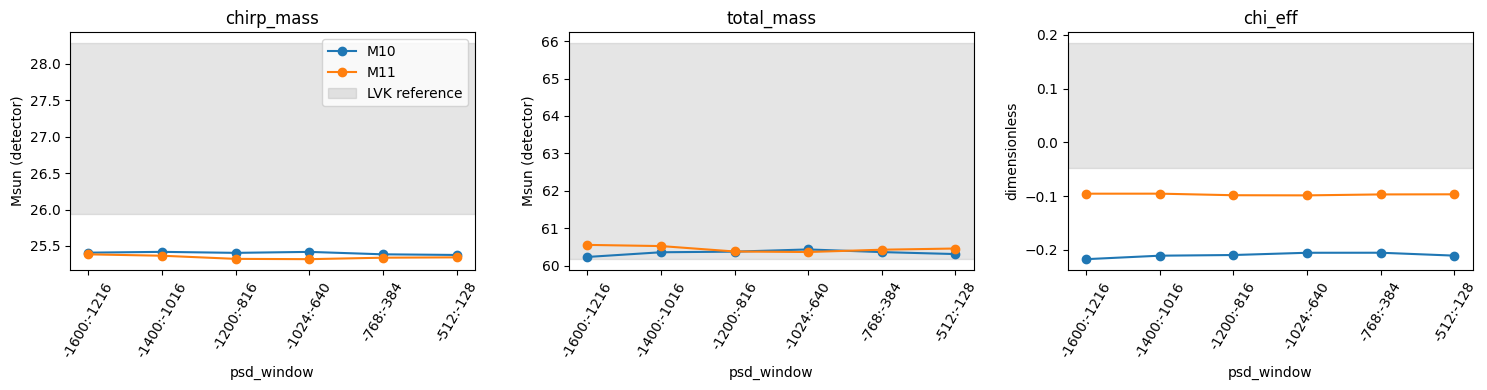

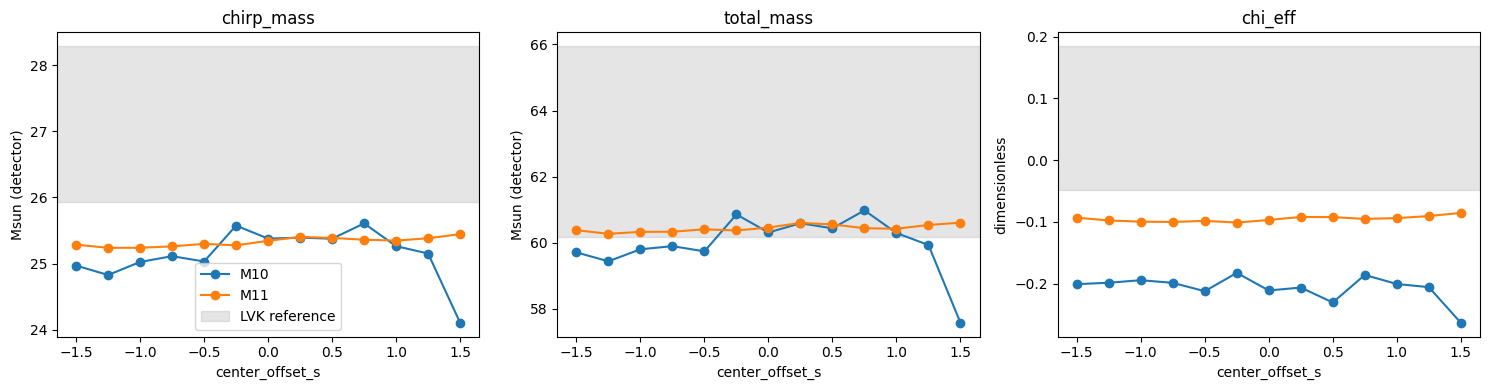

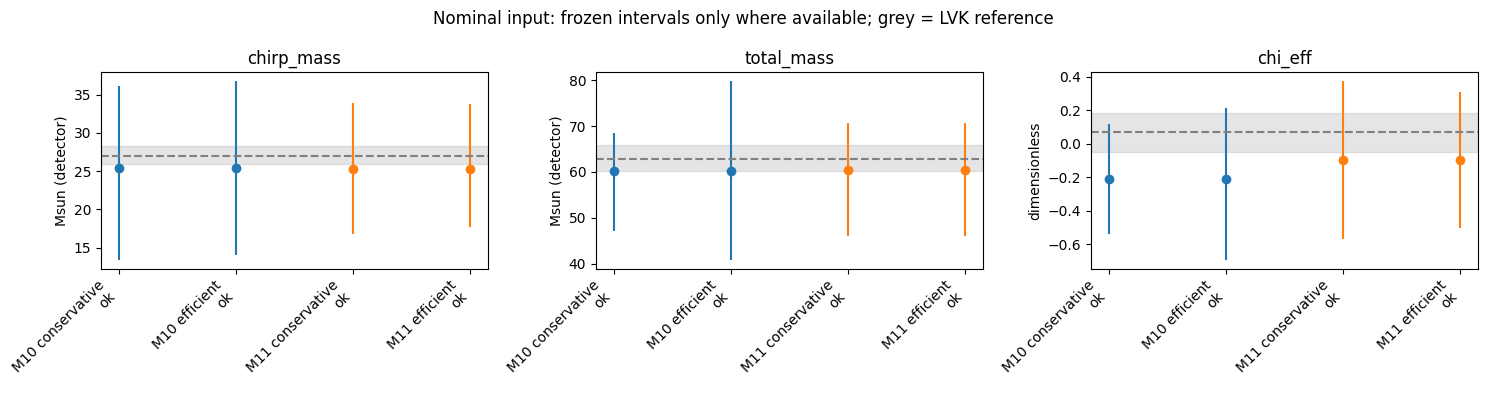

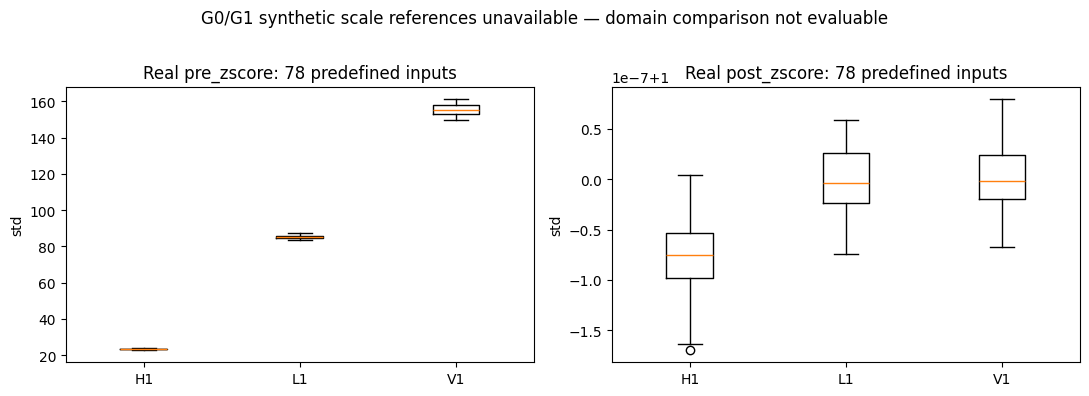

In [25]:
figures = {}
for kind, subset, xcol in [
    ("prediction_vs_psd", predictions.query("center_offset_s == 0"), "psd_window"),
    ("prediction_vs_timing", predictions.query("psd_window == @nominal_index"), "center_offset_s")]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, label in zip(axes, LABELS):
        for m in models:
            table = subset[(subset.model == m) & (subset.label == label)].sort_values(xcol)
            ax.plot(table[xcol], table.pred_phys, "o-", label=m)
        ax.axhspan(lvk[f"{label}_lvk_lower"], lvk[f"{label}_lvk_upper"], color="grey", alpha=.2, label="LVK reference")
        ax.set(title=label, xlabel=xcol, ylabel="Msun (detector)" if label != "chi_eff" else "dimensionless")
        if xcol == "psd_window":
            ax.set_xticks(range(len(PSD_WINDOWS)))
            ax.set_xticklabels([f"{a:g}:{b:g}" for a,b in PSD_WINDOWS], rotation=60)
    axes[0].legend()
    fig.tight_layout()
    figures[kind] = fig

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
nominal = lvk_comparison.query("center_offset_s == 0 and psd_window == @nominal_index")
for ax, label in zip(axes, LABELS):
    table = nominal[nominal.label == label].reset_index(drop=True)
    for i, row in table.iterrows():
        ax.plot(i, row.pred_phys, "o", color="C0" if row.model == "M10" else "C1")
        if row.interval_status == "ok":
            ax.vlines(i, row.lower_phys, row.upper_phys, color="C0" if row.model == "M10" else "C1")
    ax.axhspan(lvk[f"{label}_lvk_lower"], lvk[f"{label}_lvk_upper"], color="grey", alpha=.2)
    ax.axhline(lvk[f"{label}_lvk"], color="grey", linestyle="--")
    ax.set_xticks(range(len(table)))
    ax.set_xticklabels([f"{r.model} {r.final_policy}\n{r.interval_status}" for r in table.itertuples()], rotation=45, ha="right")
    ax.set(title=label, ylabel="Msun (detector)" if label != "chi_eff" else "dimensionless")
fig.suptitle("Nominal input: frozen intervals only where available; grey = LVK reference")
fig.tight_layout()
figures["interval_lvk_nominal"] = fig

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, stage in zip(axes, ("pre_zscore", "post_zscore")):
    data = preprocessing_diagnostics.query("stage == @stage")
    ax.boxplot([data[data.detector == ifo]["std"].values for ifo in DETECTORS], labels=DETECTORS)
    ax.set(title=f"Real {stage}: 78 predefined inputs", ylabel="std")
fig.suptitle("G0/G1 synthetic scale references unavailable — domain comparison not evaluable")
fig.tight_layout()
figures["domain_scale_availability"] = fig
plt.show()

## 14. Guardar artefactos y provenance

Sólo al ejecutar esta sección se escribe en el directorio de resultados nuevo.
Los artefactos incluyen estados faltantes; un CSV con NaN no equivale a análisis
conformal completado. No se guardan targets reales ni métricas de cobertura.

In [26]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
tables = {
    "path_audit": path_audit, "contracts": contracts, "acquisition": acquisition,
    "lvk_detector_frame_reference": lvk_event,
    "lvk_source_summary_audit": pd.DataFrame([lvk_source_row]),
    "lvk_summary_detector_frame_audit": lvk_summary_detector,
    "lvk_posterior_original_fields": posterior_original_summary,
    "preprocessing_diagnostics": preprocessing_diagnostics, "predictions": predictions,
    "input_manifest": input_manifest, "interval_results": interval_results,
    "psd_window_sensitivity": psd_sensitivity, "timing_sensitivity": timing_sensitivity,
    "timing_deviations": timing_deviations, "lvk_comparison": lvk_comparison,
    "m10_vs_m11_summary": summary, "stability_psd_comparison": stability_psd,
    "stability_timing_comparison": stability_timing, "real_scale_summary": real_scale_summary,
    "domain_availability": domain_availability, "conformal_status": pd.DataFrame(conformal_status),
}
for name, table in tables.items():
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
for name, fig in figures.items():
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=160, bbox_inches="tight")
np.savez_compressed(OUTPUT_DIR / "predictions_embeddings.npz",
    sample_index=input_manifest.sample_index.to_numpy(), label_names=np.array(LABELS),
    **{f"{m}_{key}": arr for m, arrays in inference_arrays.items() for key, arr in arrays.items()})
source_paths = [PROJECT_ROOT / "notebooks/12_real_event_inference_m10_500k_clean.ipynb",
    PROJECT_ROOT / "notebooks/13_real_events_m10_500k_lvk_comparison_clean.ipynb",
    PROJECT_ROOT / "notebooks/m11/M11_11_final_cnn_evaluation.ipynb",
    PROJECT_ROOT / "notebooks/m11/M11_12_final_mondrian_evaluation.ipynb",
    PROJECT_ROOT / "src/processing.py", PROJECT_ROOT / "src/models/network.py",
    PROJECT_ROOT / "src/models/evaluate.py", PROJECT_ROOT / "src/config.py",
    PROJECT_ROOT / "src/conformal/selected_calibrators.py", PROJECT_ROOT / "src/conformal/pipeline.py",
    PROJECT_ROOT / "src/evaluation/lvk.py", PROJECT_ROOT / "src/real_data/lvk_reference.py",
    PROJECT_ROOT / "notebooks/m11/M11_13_real_event_domain_transfer.ipynb", LVK_PATH, LVK_POSTERIOR_PATH, M11_CONFORMAL_PROVENANCE,
    *TRAIN_PATHS.values(), *GEN_PATHS.values(), *CHECKPOINTS.values(), *SELECTION_PATHS.values()]
provenance = dict(event=EVENT, event_gps=event_time, detector_order=DETECTORS,
    psd_windows=PSD_WINDOWS, center_offsets=CENTER_OFFSETS.tolist(), psd_anchor="shifted_center",
    psd_segment_duration=8.0, psd_delta_f=processing_delta_f, psd_length=processing_flength,
    psd_conditioning="at PSD estimation AND inside SignalProcessor; inherited M10",
    preprocessing=processor.metadata(), input_shape=[1,3,16384], zscore_count=1,
    zscore_eps=1e-6, std_ddof=0, models=checkpoint_metadata,
    label_scalers={m: dict(y_mean=a.tolist(), y_std=b.tolist()) for m,(a,b) in scalers.items()},
    frame="detector masses Msun; chi_eff dimensionless", lvk_reference=lvk_reference_provenance,
    lvk_interval_method="5th/50th/95th percentiles of official detector-frame Overall_posterior",
    files_sha256={str(p): sha256(p) for p in source_paths},
    strain_files=[dict(detector=k, path=str(p), sha256=sha256(p)) for k,p in strain_paths.items()],
    prediction_metadata_paths={k:str(p) for k,p in PREDICTION_PATHS.items()},
    conformal_status=conformal_status, conformal_recalibration=False, conformal_reselection=False,
    domain_evidence="not_evaluable_missing_traceable_synthetic_summaries",
    limitations=["single event", "different synthetic datasets, not paired training sources",
                 "M10 test selection vs M11 val selection", "synthetic conformal coverage does not transfer automatically",
                 "timing shifts PSD windows too", "LVK is posterior reference, not truth; summary conversion retained separately as audit",
                 "GW170814 absent from historical GWTC-3 CSV; official GWTC-1 Overall_posterior used"],
    versions=dict(python=platform.python_version(), numpy=np.__version__, torch=torch.__version__))
(OUTPUT_DIR / "provenance.json").write_text(json.dumps(provenance, indent=2), encoding="utf-8")
print("Saved:", OUTPUT_DIR)
print("Conformal analysis complete:", all(x["status"] == "loaded_frozen_state" for x in conformal_status))

Saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/real_events/GW170814
Conformal analysis complete: True


## 15. Final summary template — completar sólo con resultados

- **Point-estimate transfer:** [discrepancias emparejadas frente a LVK; nominal y todas las ventanas; preservar empeoramientos].
- **PSD-window robustness:** [std/rango a offset cero y por offset; M11−M10].
- **Timing robustness:** [std/rango/desviación del centro con PSD nominal y restantes; PSD también se desplaza].
- **Conformal uncertainty transfer:** [pendiente de estados ajustados congelados; después, ancho y solapamiento por label/política; sin garantía de cobertura real].
- **Evidence for/against reduced synthetic-real domain gap:** [no evaluable con los resúmenes sintéticos disponibles; no inferir reducción sólo por cercanía a LVK ni por std≈1].
- **Remaining limitations:** [un evento, posterior LVK condicionado a su modelo, fuentes sintéticas no emparejadas, políticas SNR/generación/selección distintas, disponibilidad conformal y diagnóstica].
- **Decision on multi-event validation:** [pendiente; requiere resolver el estado conformal, congelar eventos y política de calidad/PSD antes de consultar resultados, reutilizar la convención LVK, informar exclusiones y resultados nulos; no reoptimizar predictor/calibración].

### Trazabilidad de reutilización

Notebook 12: GPS/URLs (19), descarga/lectura (20), PSD (25), construcción con contexto
y crop (26), z-score (17), extracción de predicciones/embeddings y transformada física
(16), ventanas PSD (38), offsets (42). Se eliminan dependencias de `X_probe` no definido,
escalers globales, valores de predicción hardcoded y comentarios heredados M08.
Notebook 13: convención de frame, propagación LVK y métricas compartidas;
el CSV GWTC-3 no contiene este evento; se usan las muestras oficiales GWTC-1
y se conserva el summary v3 con la conversión histórica como auditoría separada. M11.11: identidad del
predictor/scaler y lectura de metadata. M11.12: decisiones congeladas, roles cal/val/test,
y ausencia explícita de estado ajustado serializado. No se ejecutan sus notebooks.

### Validación técnica de entrega (no evaluación científica completa)

Se verificó sintaxis Python 3.10 de todas las celdas; se cargaron ambos checkpoints
y se contrastaron sus contratos/scalers con los NPZ. Los helpers de descarga/lectura,
PSD, construcción y z-score, así como ventanas/offsets, se contrastaron con el AST
del notebook 12. Se comprobó cobertura/finitud del strain cacheado para toda la
rejilla predefinida, y se procesó **una sola entrada nominal** con ambos modelos:
shape (1,3,16384), finitud, z-score una vez y predicciones M10 reproducidas a la
precisión mostrada por el notebook histórico. Se probaron las tablas, la ruta de
calibradores ausentes y las figuras con esa entrada, sin guardar resultados.
La referencia posterior oficial se verificó por checksum, campos y frame.

No se ejecutó el barrido 78 entradas ni datasets sintéticos completos. No se pudo
probar la carga/aplicación de bundles científicos reales porque todavía no existen;
se validarán al proporcionarlos. El notebook se entrega sin outputs ni conclusiones
científicas rellenadas. Sólo se ha creado/modificado este notebook en el repositorio.


## 15. Conclusions

This notebook evaluated the transfer of the frozen M10 and M11 pipelines to
the real event GW170814 using identical H1/L1/V1 strain, predefined PSD
windows and timing offsets. CNN predictors and Mondrian systems were kept
fully frozen throughout the analysis.

### Point-estimate transfer

At the nominal PSD window and zero timing offset, M11 does not produce a
uniform improvement relative to the GWTC-1 posterior reference.

For chirp mass, M10 and M11 give very similar results, with absolute
discrepancies from the LVK posterior median of approximately 1.68 and
1.71 Msun, respectively. Total mass improves slightly, from approximately
2.46 Msun for M10 to 2.31 Msun for M11.

The largest change occurs for effective spin. The M10 prediction is about
-0.211, whereas M11 predicts about -0.097, compared with an LVK posterior
median of approximately +0.067. The M11 estimate therefore remains offset
from the LVK posterior and retains the opposite sign, but its absolute
discrepancy decreases from approximately 0.278 to 0.164.

The real-event results therefore do not support a uniform statement that
M11 improves all point estimates, but they also show no evidence of a
general degradation.

### Timing robustness

The clearest improvement produced by M11 is its substantially reduced
sensitivity to the position of the event within the analysed 4-s segment.

For the nominal PSD window, the prediction standard deviation across the
13 predefined timing offsets decreases relative to M10 by approximately:

- 83% for chirp mass,
- 87% for total mass,
- 79% for chi_eff.

The corresponding prediction ranges decrease by approximately 86%, 90%
and 81%, respectively.

This represents a large improvement in real-event temporal robustness and
is consistent with the changes introduced in the M11 data-generation and
signal-context pipeline.

### PSD-window robustness

The effect of changing the off-source PSD window is more heterogeneous.

At zero timing offset, chi_eff becomes substantially more stable in M11,
whereas chirp mass shows a modest increase in variation across PSD windows.
Total mass remains broadly comparable between M10 and M11.

Consequently, M11 should not be interpreted as eliminating sensitivity to
PSD estimation. Its strongest robustness gain in GW170814 is associated
with timing placement rather than with PSD-window choice.

### Conformal uncertainty transfer

The frozen M10 and M11 Mondrian calibrators were successfully applied
without refitting or reselection.

For the nominal configuration, the selected M11 intervals overlap the
GWTC-1 posterior reference for all three inferred parameters. The mass
intervals remain broadly compatible with the LVK posterior, while the
chi_eff interval accommodates the residual discrepancy of the M11 point
prediction.

These real-event overlaps must not be interpreted as an empirical
verification of the nominal 90% conformal coverage. The conformal systems
were calibrated on synthetic data, and exchangeability between the
synthetic and real domains is not established.

### Evidence for reduced synthetic-to-real domain gap

The present experiment provides indirect evidence of improved real-data
transfer, particularly through the strong reduction in timing sensitivity
and the improved chi_eff point estimate.

However, a direct quantitative claim that the M11/G1 synthetic domain is
closer to real detector data than the M10/G0 domain cannot yet be made.
Traceable and directly comparable synthetic input summaries were not
available in this notebook, and the final per-sample z-score normalization
removes the detector-scale differences that originally motivated part of
the domain-gap study.

Therefore, the current evidence supports improved operational robustness
of M11 on GW170814, but not a direct measurement of reduced distributional
distance between G1 and real data.

### Decision

GW170814 provides sufficient evidence to proceed to a frozen multi-event
validation.

The multi-event study should reuse the current M10/M11 predictors,
preprocessing contracts and frozen Mondrian calibrators without further
optimization. Its purpose is to determine whether the behaviour observed
here—especially the improvement in timing robustness and chi_eff
inference—generalizes beyond a single event.

Predictor optimization, alternative Mondrian taxonomies, regression-to-the-
mean mitigation and more detailed synthetic-to-real distance diagnostics
are deferred until after the multi-event validation.